In [83]:
import numpy as np

C = 299792458.0
# LALSuite detector parameters (lat, lon in deg; x-arm azimuth deg E of N)
# (lat, lon, x-arm azimuth, y-arm azimuth) -- azimuth = compass bearing,
# clockwise from North.  LHO x-arm N36.0W, y-arm N126.0W;
# LLO x-arm S72.2835W, y-arm S17.7165E;  Virgo x-arm N70.5674E, y N160.5674E.
DET = {"H1": (46.45514, -119.40765, 324.0000, 234.0000),
       "L1": (30.56289,  -90.77424, 252.2835, 162.2835),
       "V1": (43.63130,   10.50450,  70.5674, 160.5674)}

def det_geom(lat, lon, azi_x, azi_y):
    la, lo = np.radians(lat), np.radians(lon)
    r = 6.378137e6*np.array([np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo),
                             np.sin(la)])
    # local East, North, Up
    E = np.array([-np.sin(lo), np.cos(lo), 0.0])
    Nn = np.array([-np.sin(la)*np.cos(lo), -np.sin(la)*np.sin(lo), np.cos(la)])
    def arm_vec(a):
        a = np.radians(a)
        return np.cos(a)*Nn + np.sin(a)*E
    u, v = arm_vec(azi_x), arm_vec(azi_y)
    D = 0.5*(np.outer(u, u) - np.outer(v, v))
    return r, D

def orf(d1, d2, f, nside=220):
    """gamma_12(f) by direct sky integration, normalised so that two
       co-located co-aligned detectors give gamma = 1."""
    r1, D1 = det_geom(*DET[d1]); r2, D2 = det_geom(*DET[d2])
    dr = r1 - r2
    # equal-area sky grid
    ct = np.linspace(-1, 1, nside, endpoint=False) + 1.0/nside
    ph = np.linspace(0, 2*np.pi, 2*nside, endpoint=False) + np.pi/(2*nside)
    CT, PH = np.meshgrid(ct, ph, indexing="ij")
    st = np.sqrt(1 - CT**2)
    n = np.stack([st*np.cos(PH), st*np.sin(PH), CT], axis=-1)     # (..,3)
    # polarisation basis
    ex = np.stack([np.cos(CT*0)*np.sin(PH), -np.cos(PH), np.zeros_like(CT)], -1)
    ey = np.stack([CT*np.cos(PH), CT*np.sin(PH), -st], -1)
    ep = np.einsum("...i,...j->...ij", ex, ex) - np.einsum("...i,...j->...ij", ey, ey)
    ec = np.einsum("...i,...j->...ij", ex, ey) + np.einsum("...i,...j->...ij", ey, ex)
    F1p = np.einsum("...ij,ij->...", ep, D1); F1c = np.einsum("...ij,ij->...", ec, D1)
    F2p = np.einsum("...ij,ij->...", ep, D2); F2c = np.einsum("...ij,ij->...", ec, D2)
    S = F1p*F2p + F1c*F2c
    phase_arg = 2*np.pi*np.einsum("...i,i->...", n, dr)/C
    dOm = (2.0/nside)*(2*np.pi/(2*nside))
    f = np.atleast_1d(f)
    g = np.array([np.sum(S*np.cos(phase_arg*ff))*dOm for ff in f])
    return (5.0/(8*np.pi))*g

if __name__ == "__main__":
    print("gamma_HL(0)  =", orf("H1", "L1", [0.0])[0],
          "   (expected about -0.89)")
    print("gamma_HH(0)  =", orf("H1", "H1", [0.0])[0], "   (expected 1.0)")
    ff = np.linspace(1, 120, 2000)
    g = orf("H1", "L1", ff)
    z = ff[:-1][np.sign(g[:-1]) != np.sign(g[1:])]
    print("first zeros [Hz]:", np.round(z[:3], 2), "   (expected ~64, 128 ...)")
    r1, _ = det_geom(*DET["H1"]); r2, _ = det_geom(*DET["L1"])
    print("H-L light travel time [ms]:",
          round(np.linalg.norm(r1 - r2)/C*1e3, 3))
    r3, _ = det_geom(*DET["V1"])
    print("L-V light travel time [ms]:",
          round(np.linalg.norm(r2 - r3)/C*1e3, 3))


# ---------------------------------------------------------------------------
# Exact 1-D reduction:  gamma(f) = (5/8pi) \int_{-1}^{1} g(mu) cos(2 pi f d mu/c) dmu
# where mu = n.shat and g(mu) is the azimuthal integral of F1.F2 around shat.
# This is machine-precision at every f, so second differences are trustworthy.
def orf_kernel(d1, d2, nmu=600, nphi=256):
    r1, D1 = det_geom(*DET[d1]); r2, D2 = det_geom(*DET[d2])
    dr = r1 - r2; d = np.linalg.norm(dr)
    sh = dr/d if d > 0 else np.array([0., 0., 1.])
    a = np.array([1., 0., 0.])
    if abs(np.dot(a, sh)) > 0.9:
        a = np.array([0., 1., 0.])
    e1 = np.cross(sh, a); e1 /= np.linalg.norm(e1); e2 = np.cross(sh, e1)

    mu, wmu = np.polynomial.legendre.leggauss(nmu)
    ph = np.arange(nphi)*2*np.pi/nphi
    sm = np.sqrt(1 - mu**2)
    n = (mu[:, None, None]*sh + sm[:, None, None]*(np.cos(ph)[None, :, None]*e1
         + np.sin(ph)[None, :, None]*e2))                       # (nmu,nphi,3)
    # any polarisation basis works: F1p F2p + F1c F2c is basis independent
    ref = np.array([0., 0., 1.])
    ex = np.cross(n, ref); nn = np.linalg.norm(ex, axis=-1, keepdims=True)
    bad = (nn[..., 0] < 1e-8)
    ex = np.where(nn > 1e-8, ex/np.where(nn > 1e-8, nn, 1), np.array([1., 0., 0.]))
    ex[bad] = np.array([1., 0., 0.])
    ey = np.cross(n, ex)
    ep = np.einsum("...i,...j->...ij", ex, ex) - np.einsum("...i,...j->...ij", ey, ey)
    ec = np.einsum("...i,...j->...ij", ex, ey) + np.einsum("...i,...j->...ij", ey, ex)
    S = (np.einsum("...ij,ij->...", ep, D1)*np.einsum("...ij,ij->...", ep, D2)
         + np.einsum("...ij,ij->...", ec, D1)*np.einsum("...ij,ij->...", ec, D2))
    g = S.mean(axis=1)*2*np.pi                    # azimuthal integral
    return mu, wmu*g, d

def orf_fast(d1, d2, f):
    mu, wg, d = orf_kernel(d1, d2)
    a = 2*np.pi*np.atleast_1d(f)*d/C
    return (5.0/(8*np.pi))*(wg[None, :]*np.cos(a[:, None]*mu[None, :])).sum(1)

if __name__ == "__main__":
    ft = np.array([0., 5., 20., 64.34, 100., 300., 1000.])
    a, b = orf_fast("H1", "L1", ft), orf("H1", "L1", ft)
    print("\nexact 1-D vs direct sky integral:")
    for x, u, v in zip(ft, a, b):
        print(f"   f={x:7.2f}  1D={u:+.8f}   sky={v:+.8f}   diff={u-v:+.2e}")
    print("   gamma_fast(0) =", round(orf_fast("H1", "L1", [0.])[0], 6))

gamma_HL(0)  = -0.8910589234494424    (expected about -0.89)
gamma_HH(0)  = 0.9999986628057708    (expected 1.0)
first zeros [Hz]: [ 64.34 116.37]    (expected ~64, 128 ...)
H-L light travel time [ms]: 10.014
L-V light travel time [ms]: 26.42

exact 1-D vs direct sky integral:
   f=   0.00  1D=-0.89105899   sky=-0.89105892   diff=-6.23e-08
   f=   5.00  1D=-0.88091630   sky=-0.88091621   diff=-8.62e-08
   f=  20.00  1D=-0.73801445   sky=-0.73801426   diff=-1.99e-07
   f=  64.34  1D=-0.00029847   sky=-0.00031476   diff=+1.63e-05
   f= 100.00  1D=+0.06935716   sky=+0.06929929   diff=+5.79e-05
   f= 300.00  1D=+0.00820478   sky=+0.00781015   diff=+3.95e-04
   f=1000.00  1D=+0.00060430   sky=-0.00068820   diff=+1.29e-03
   gamma_fast(0) = -0.891059


In [ ]:
"""
Fit a smooth ANALYTIC model to a tabulated PSD, for use in the window-
approximation study.

Motivation
----------
eps_l involves a discrete SECOND DIFFERENCE of H = P_n, evaluated on a grid
far finer than the PSD table.  Any interpolant inherits the bin-to-bin jitter
of the file and the second difference amplifies it.  An analytic model is
smooth by construction: H'' is then a property of the model, not of the file.

The model is a polynomial in log-log space,

    ln P(f) = sum_k a_k T_k(x),     x = normalised ln(f),

with T_k the Chebyshev basis.  The DEGREE is the low-pass knob: too low and
the model misses real structure, too high and it starts reproducing the
jitter you are trying to remove.  Section 3 scans it so you can choose.

Usage
-----
    python fit_psd_analytic.py PSD_FILE [FMIN] [FMAX]

Then paste the emitted `psd_ce_fit` into the main script and set
PSD_FILE = None-style analytic evaluation.
"""

import sys
import numpy as np
from numpy.polynomial import Chebyshev

# ---------------------------------------------------------------- config
DEGREES = range(4, 25)      # degrees to scan
DEG_PICK = None             # set to an int to skip the scan and use that degree
TARGET = 1e-3               # relative accuracy we are willing to accept


# ============================================================ 1. load
def load_table(path, fmin, fmax, pad=1.2):
    tab = np.genfromtxt(path)
    fc, Pc = tab[:, 0], tab[:, 1]
    ok = np.isfinite(fc) & np.isfinite(Pc) & (fc > 0) & (Pc > 0)
    fc, Pc = fc[ok], Pc[ok]
    o = np.argsort(fc)
    fc, Pc = fc[o], Pc[o]

    m = (fc >= fmin/pad) & (fc <= fmax*pad)
    if m.sum() < 30:
        raise ValueError(f"only {m.sum()} points in the fitting range")

    print(f"table: {fc.size} points, {fc.min():.4g} - {fc.max():.4g} Hz")
    if fc.min() > fmin or fc.max() < fmax:
        print(f"  WARNING: table does not cover [{fmin:g}, {fmax:g}] Hz")
    d = np.diff(np.log(fc[m]))
    print(f"  fitting on {m.sum()} points, {fc[m].min():.4g} - "
          f"{fc[m].max():.4g} Hz; "
          f"{'log' if d.max()/d.min() < 1.5 else 'non-log'}-spaced in ln f")
    return fc[m], Pc[m]


# ============================================================ 2. fit
def fit(fc, Pc, deg):
    """Least squares for ln P as a Chebyshev series in ln f.

    Uniform weights in ln f.  For a log-spaced table this weights every
    decade equally, which is what we want: the relative accuracy of P
    matters, not its absolute value.  For a LINEARLY spaced table the high
    frequencies would dominate -- resample in ln f first if that is the case.
    """
    return Chebyshev.fit(np.log(fc), np.log(Pc), deg)


def curvature(cheb, lnf):
    """d^2 ln P / d(ln f)^2 of the model -- the quantity eps_l is sensitive
    to.  For a pure power law this vanishes, so it measures departure from
    power-law behaviour."""
    return cheb.deriv(2)(lnf)


def raw_curvature(fc, Pc):
    """Same quantity from the raw table, with the non-uniform-grid three
    point formula.  Comparing it with `curvature` shows how much structure
    the fit has discarded -- and how much of that structure was noise."""
    lf, lP = np.log(fc), np.log(Pc)
    h0, h1 = lf[1:-1] - lf[:-2], lf[2:] - lf[1:-1]
    return lf[1:-1], 2.0*((lP[2:] - lP[1:-1])/h1
                          - (lP[1:-1] - lP[:-2])/h0)/(h0 + h1)


# ============================================================ 3. scan
def scan(fc, Pc, fmin, fmax):
    inband = (fc >= fmin) & (fc <= fmax)
    lf_r, d2_raw = raw_curvature(fc, Pc)

    print(f"\n{'deg':>4s}{'max |fit/raw-1|':>18s}{'median':>11s}"
          f"{'max |d2 lnP|':>15s}{'raw d2 (99%)':>15s}")
    best = None
    for deg in DEGREES:
        c = fit(fc, Pc, deg)
        rel = np.abs(np.exp(c(np.log(fc[inband])))/Pc[inband] - 1.0)
        d2 = np.abs(curvature(c, np.log(fc[inband])))
        print(f"{deg:4d}{rel.max():18.2e}{np.median(rel):11.2e}"
              f"{d2.max():15.2e}{np.percentile(np.abs(d2_raw), 99):15.2e}")
        if best is None and rel.max() < TARGET:
            best = deg
    return best


# ============================================================ 4. emit
def emit(cheb, fmin, fmax):
    """Print a self-contained function to paste into the main script."""
    dom = cheb.domain
    co = cheb.coef
    print("\n" + "="*70)
    print(f"""
def psd_ce_fit(fr):
    \"\"\"Smooth analytic fit to the CE noise PSD, valid on
    [{fmin:.4g}, {fmax:.4g}] Hz.  ln P is a degree-{len(co)-1} Chebyshev
    series in ln f.  Smooth by construction, so the second difference
    entering eps_l is free of table jitter.  DO NOT extrapolate.\"\"\"
    from numpy.polynomial import Chebyshev
    _c = Chebyshev({np.array2string(co, precision=12, separator=', ',
                                    max_line_width=68)},
                   domain=[{dom[0]:.12g}, {dom[1]:.12g}])
    return np.exp(_c(np.log(fr)))
""")
    print("="*70)

In [126]:
path = "./Data/CE_40_PSD.txt"
fmin = 10.0
fmax = 1726.0

fc, Pc = load_table(path, fmin, fmax)

deg = DEG_PICK
if deg is None:
    deg = scan(fc, Pc, fmin, fmax)
    if deg is None:
        deg = max(DEGREES)
        print(f"\nno degree reached {TARGET:.0e}; using {deg}")
    else:
        print(f"\nlowest degree meeting {TARGET:.0e}: {deg}")

c = fit(fc, Pc, deg)

inband = (fc >= fmin) & (fc <= fmax)
rel = np.abs(np.exp(c(np.log(fc[inband])))/Pc[inband] - 1.0)
print(f"\ndegree {deg}: max |fit/raw - 1| = {rel.max():.2e} at "
      f"{fc[inband][rel.argmax()]:.4g} Hz, median {np.median(rel):.2e}")

emit(c, fmin, fmax)

table: 1000 points, 5 - 5000 Hz
  fitting on 798 points, 8.341 - 2063 Hz; log-spaced in ln f

 deg   max |fit/raw-1|     median   max |d2 lnP|   raw d2 (99%)
   4          1.95e-01   6.83e-02       3.87e+00       5.60e+01
   5          1.15e-01   2.20e-02       6.80e+00       5.60e+01
   6          1.32e-01   1.27e-02       8.46e+00       5.60e+01
   7          1.23e-01   4.48e-03       9.58e+00       5.60e+01
   8          1.24e-01   5.29e-03       9.33e+00       5.60e+01
   9          1.17e-01   3.14e-03       8.03e+00       5.60e+01
  10          1.16e-01   1.77e-03       7.40e+00       5.60e+01
  11          1.18e-01   7.38e-04       7.35e+00       5.60e+01
  12          1.18e-01   7.42e-04       7.35e+00       5.60e+01
  13          1.18e-01   8.57e-04       7.27e+00       5.60e+01
  14          1.18e-01   5.87e-04       7.11e+00       5.60e+01
  15          1.17e-01   2.83e-04       6.95e+00       5.60e+01
  16          1.17e-01   2.99e-04       6.96e+00       5.60e+01
  17      

(10, 1728)

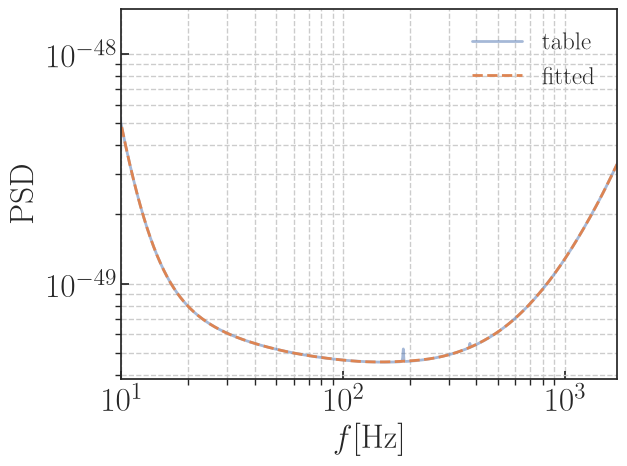

In [143]:
plt.loglog(fc, Pc, label="table", lw=2, alpha=0.5)
plt.loglog(fc[inband], np.exp(c(np.log(fc[inband]))), ls="--", lw=2, label="fitted")
plt.legend()
plt.xlabel(r"$f$[Hz]")
plt.ylabel("PSD")
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(direction='in')
plt.xlim(10, 1728)


T = 192.0 s, Delta f = 0.00521 Hz, band 10.0-1726.0 Hz, H1-L1, alpha = 0.6667
window                  median |eps|  <eps>_w (sig)  <eps>_w (noi)   rel.
sine                        1.38e-08      +1.22e-07      +2.21e-07   0.75
Welch                       1.39e-08      +1.23e-07      +2.24e-07   0.76
Hamming                     1.46e-08      +1.30e-07      +2.35e-07   0.80
Bartlett                    1.67e-08      +1.48e-07      +2.69e-07   0.91
Hann                        1.83e-08      +1.63e-07      +2.95e-07   1.00
Tukey $\alpha=0.5$          2.00e-08      +1.77e-07      +3.22e-07   1.09
Kaiser $\beta=8$            2.32e-08      +2.05e-07      +3.72e-07   1.26
Blackman                    2.49e-08      +2.21e-07      +4.00e-07   1.36
Nuttall                     3.32e-08      +2.94e-07      +5.33e-07   1.81
Kaiser $\beta=14$           3.98e-08      +3.53e-07      +6.40e-07   2.17
Tukey $\alpha=0.1$          7.33e-08      +6.51e-07      +1.18e-06   4.00

Hann, H = gamma P_gw : median 1.

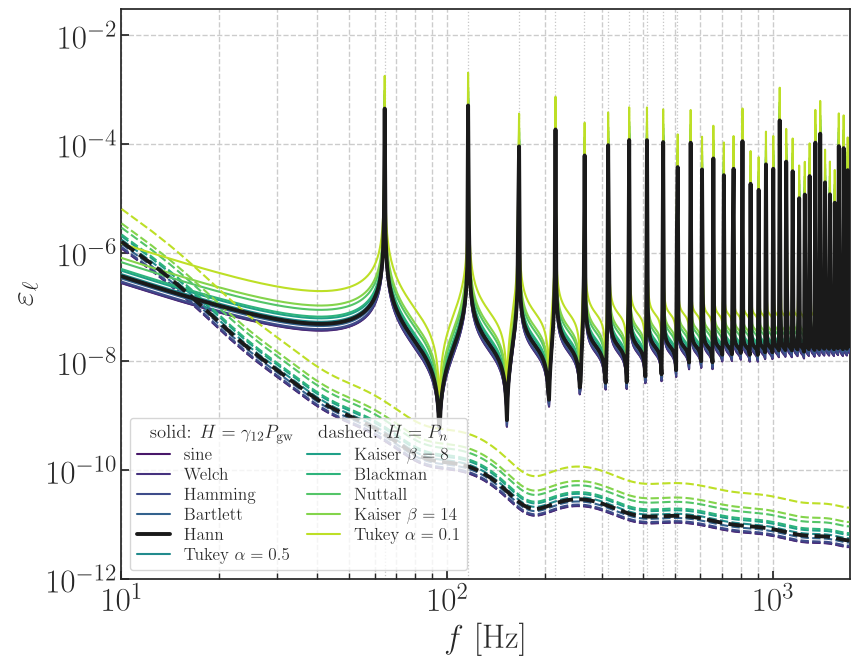

In [145]:
"""
Exact fractional error of the Eq. (4.3) -> (4.4) reduction, for any window.

                     | (K * H)_l - H_l |          |w~_m|^2
    eps_l  =         | ---------------- | ,  K_m = --------- ,  sum_m K_m = 1
                     |        H_l       |             W

It is evaluated in the equivalent but numerically safe form

    (K * H)_l - H_l = sum_m K_m ( H_{l-m} - H_l )                        (*)

so that the small quantity is formed directly instead of as the difference of
two nearly equal numbers.

Outputs: a table of sensitivity-weighted biases, and the appendix figure.
"""

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import get_window
from scipy.interpolate import UnivariateSpline



# =====================================================================
# 1.  CONFIGURATION  -- everything you normally need to touch is here
# =====================================================================
FS      = 4096.0        # Hz   sampling rate of the strain data
T       = 192.0          # s    segment length  ->  Delta f = 1/T
df = 1.0/T
FMIN    = 10.0          # Hz   low edge of the analysis band
FMAX    = 1726.0        # Hz   high edge of the analysis band
ALPHA   = 2.0/3.0       #      Omega_gw ~ f^ALPHA
F_LOW = max([1.0, FMIN - 300*df])   # Hz   spectrum taken to be zero below this
DETS    = ("H1", "L1")  #      detector pair for the ORF

PSD_FILE   = "./Data/CE_40_for_paper_PSD.txt"   
PSD_SMOOTH = 1e-9       # smoothing-spline strength (see load_psd below)

# =====================================================================
# 2.  FREQUENCY GRID
# =====================================================================
N  = int(FS*T)          # samples per segment = number of DFT bins

# Folded frequency: DFT bins j and N-j are the same physical frequency for a
# real time series, so H is a real, even sequence on the circle.  The exact
# convolution runs over the whole circle, not over positive frequencies only.
jj = np.arange(N)
f  = np.minimum(jj, N - jj)*df

inband = (f >= F_LOW) & (f <= FS/2)

# =====================================================================
# 3.  THE TWO SPECTRAL COMBINATIONS  H
# =====================================================================
gam = np.zeros(N)
gam[inband] = orf_fast(DETS[0], DETS[1], f[inband])

P = np.zeros(N)
P[inband] = np.exp(c(np.log(f[inband])))


S0 = np.zeros(N)
S0[inband] = f[inband]**(ALPHA - 3.0)          # P_gw shape; normalisation drops out

H_SIG = gam*S0                                  # H = gamma_12 P_gw   (Eq. 4.3)
H_NOI = P.copy()                                # H = P_1             (variance terms)

# bins at which eps_l is evaluated, and the sensitivity weight of each
sel = np.arange(int(round(FMIN/df)), int(round(FMAX/df)) + 1)
fi  = f[sel]
wgt = (gam[sel]*S0[sel])**2/(P[sel]*P[sel])

# =====================================================================
# 4.  WINDOWS
# =====================================================================
WINDOWS = {
    "Hann":                 get_window("hann",     N, fftbins=True),
    "Hamming":              get_window("hamming",  N, fftbins=True),
    "Blackman":             get_window("blackman", N, fftbins=True),
    "Nuttall":              get_window("nuttall",  N, fftbins=True),
    "sine":                 np.sin(np.pi*np.arange(N)/N),
    "Welch":                1 - ((np.arange(N) - N/2)/(N/2))**2,
    "Bartlett":             get_window("bartlett", N, fftbins=True),
    r"Tukey $\alpha=0.5$":  get_window(("tukey",  0.5), N, fftbins=True),
    r"Tukey $\alpha=0.1$":  get_window(("tukey",  0.1), N, fftbins=True),
    r"Kaiser $\beta=8$":    get_window(("kaiser",  8.), N, fftbins=True),
    r"Kaiser $\beta=14$":   get_window(("kaiser", 14.), N, fftbins=True),
}

# =====================================================================
# 5.  EXACT eps_l
# =====================================================================
# Circular distance |m|: bin m = N-1 is the neighbour m = -1, not a far one.
mi_all   = np.arange(N)
mdist    = np.minimum(mi_all, N - mi_all)

M0       = 400          # PURELY a speed/stability split of the sum in (*).
                        # Terms with |m| <= M0 are summed directly (a python
                        # loop, but cancellation-free); the remaining ones are
                        # done with one FFT.  near + far is the complete sum, so
                        # the result does not depend on M0.  For a cosine-sum
                        # window K_m vanishes beyond |m| = M and 'far' is
                        # identically zero; M0 = 5 would then be enough.
near_idx = np.where(mdist <= M0)[0]


def eps(K, H):
    """Exact (K*H)_l/H_l - 1 on the bins `sel`, via Eq. (*)."""
    Hl = H[sel]

    # ---- |m| <= M0 : direct, differences taken inside the sum
    near = np.zeros(sel.size)
    for m in near_idx:
        if K[m] != 0.0:
            near += K[m]*(H[(sel - m) % N] - Hl)

    # ---- |m| > M0 : same expression, evaluated with one circular convolution
    Ktail = K.copy()
    Ktail[near_idx] = 0.0
    far = (np.real(np.fft.ifft(np.fft.fft(Ktail)*np.fft.fft(H)))[sel]
           - Ktail.sum()*Hl)

    return (near + far)/Hl


EPS_SIG, EPS_NOI = {}, {}
for name, w in WINDOWS.items():
    K = np.abs(np.fft.fft(w))**2
    K /= K.sum()                                  # K_m = |w~_m|^2 / W
    EPS_SIG[name] = eps(K, H_SIG)
    EPS_NOI[name] = eps(K, H_NOI)

# =====================================================================
# 6.  TABLE
# =====================================================================
def wavg(e):
    return np.sum(wgt*e)/np.sum(wgt)

ref = abs(wavg(EPS_SIG["Hann"]))
print(f"\nT = {T} s, Delta f = {df:.5f} Hz, band {FMIN}-{FMAX} Hz, "
      f"{DETS[0]}-{DETS[1]}, alpha = {ALPHA:.4f}")
print(f"{'window':22s}{'median |eps|':>14s}{'<eps>_w (sig)':>15s}"
      f"{'<eps>_w (noi)':>15s}{'rel.':>7s}")
for name in sorted(WINDOWS, key=lambda k: abs(wavg(EPS_SIG[k]))):
    print(f"{name:22s}{np.median(abs(EPS_SIG[name])):14.2e}"
          f"{wavg(EPS_SIG[name]):+15.2e}{wavg(EPS_NOI[name]):+15.2e}"
          f"{abs(wavg(EPS_SIG[name]))/ref:7.2f}")

e = abs(EPS_SIG["Hann"])
print(f"\nHann, H = gamma P_gw : median {np.median(e):.2e}, "
      f"99th pct {np.percentile(e, 99):.2e}, max {e.max():.2e} "
      f"at {fi[e.argmax()]:.1f} Hz")
print(f"fraction of sensitivity with |eps| > 1e-5 : "
      f"{np.sum(wgt[e > 1e-5])/np.sum(wgt):.2e}")

# =====================================================================
# 7.  FIGURE
# =====================================================================
sns.set(style='ticks', context='notebook', font='serif',
        font_scale=1.5, palette='deep')
mpl.rcParams.update({'backend': 'pdf', 'axes.labelsize': 24,
                     'axes.titlesize': 32, 'font.size': 18,
                     'legend.fontsize': 18, 'xtick.labelsize': 24,
                     'ytick.labelsize': 24, 'font.family': 'serif',
                     'font.sans-serif': ['Bitstream Vera Sans'],
                     'font.serif': ['Times New Roman'], 'text.usetex': True})


def envelope(x, y, nbins=900):
    """Per-bin MAXIMUM on a logarithmic x grid.

    fi has ~5e4 points; drawing them all makes a huge, illegible PDF.  The
    maximum (not the mean) is used so that the narrow spikes at the zeros of
    gamma_12 survive the thinning.
    """
    edges = np.logspace(np.log10(x[0]), np.log10(x[-1]), nbins + 1)
    idx = np.clip(np.searchsorted(edges, x) - 1, 0, nbins - 1)
    out = np.full(nbins, -np.inf)          # -inf, not nan: np.maximum(nan,·)=nan
    np.maximum.at(out, idx, y)             # scatter-max; plain fancy indexing
    keep = np.isfinite(out)                # would keep only the last duplicate
    return np.sqrt(edges[:-1]*edges[1:])[keep], out[keep]


# order = table order, so legend order matches the vertical order of the curves
order = sorted(WINDOWS, key=lambda k: abs(wavg(EPS_SIG[k])))
cmap = plt.get_cmap('viridis')

fig, ax = plt.subplots(figsize=(9.4, 7.4))
for i, name in enumerate(order):
    colour = 'k' if name == "Hann" else cmap(0.06 + 0.84*i/(len(order) - 1))
    lw = 2.8 if name == "Hann" else 1.5
    for series, ls, lab in [(EPS_SIG[name], '-', name),
                            (EPS_NOI[name], (0, (4, 1.6)), None)]:
        xs, ys = envelope(fi, abs(series))
        ax.plot(xs, ys, ls=ls, color=colour, lw=lw,
                zorder=5 if name == "Hann" else 3, label=lab)

# zeros of the ORF: where H_l -> 0 and the FRACTIONAL error is enhanced
zeros = fi[:-1][np.sign(gam[sel][:-1]) != np.sign(gam[sel][1:])]
for z in zeros[:10]:
    ax.axvline(z, color='0.78', lw=0.9, ls=':', zorder=0)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(FMIN, FMAX); ax.set_ylim(1e-12, 3e-2)
ax.set_xlabel(r'$f$ [Hz]')
ax.set_ylabel(r'$\varepsilon_\ell$')
ax.legend(loc='lower left', fontsize=12.5, ncol=2, handlelength=1.9,
          labelspacing=0.26, columnspacing=1.0,
          title=r'solid: $H=\gamma_{12}P_{\rm gw}$ \quad dashed: $H=P_n$',
          title_fontsize=13.5, frameon=True)
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(which='both', direction='in')
fig.savefig("window_justification_192s.pdf",bbox_inches="tight")


T = 4.0 s, Delta f = 0.25000 Hz, band 10.0-1726.0 Hz, H1-L1, alpha = 0.6667
window                  median |eps|  <eps>_w (sig)  <eps>_w (noi)   rel.
sine                        3.93e-05      +3.00e-04      +5.23e-04   0.80
Hamming                     3.37e-05      +3.01e-04      +5.56e-04   0.80
Welch                       4.54e-05      +3.13e-04      +5.31e-04   0.83
Bartlett                    4.70e-05      +3.65e-04      +6.36e-04   0.97
Hann                        4.23e-05      +3.77e-04      +6.96e-04   1.00
Tukey $\alpha=0.5$          4.61e-05      +4.12e-04      +7.66e-04   1.09
Kaiser $\beta=8$            5.33e-05      +4.77e-04      +8.80e-04   1.26
Blackman                    5.73e-05      +5.12e-04      +9.46e-04   1.36
Nuttall                     7.64e-05      +6.83e-04      +1.26e-03   1.81
Kaiser $\beta=14$           9.17e-05      +8.19e-04      +1.52e-03   2.17
Tukey $\alpha=0.1$          1.69e-04      +1.63e-03      +3.31e-03   4.31

Hann, H = gamma P_gw : median 4.23

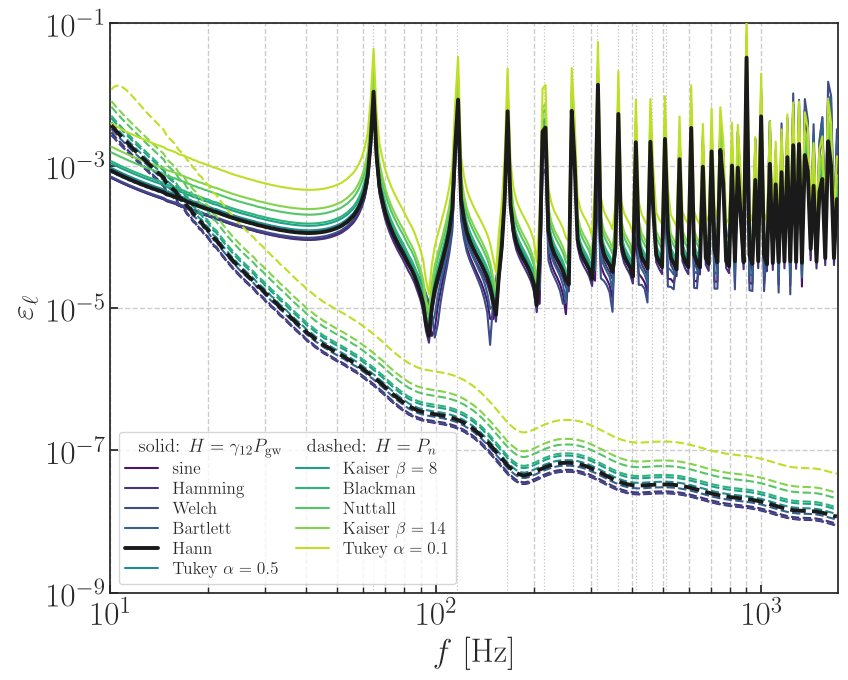

In [146]:
"""
Exact fractional error of the Eq. (4.3) -> (4.4) reduction, for any window.

                     | (K * H)_l - H_l |          |w~_m|^2
    eps_l  =         | ---------------- | ,  K_m = --------- ,  sum_m K_m = 1
                     |        H_l       |             W

It is evaluated in the equivalent but numerically safe form

    (K * H)_l - H_l = sum_m K_m ( H_{l-m} - H_l )                        (*)

so that the small quantity is formed directly instead of as the difference of
two nearly equal numbers.

Outputs: a table of sensitivity-weighted biases, and the appendix figure.
"""

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import get_window
from scipy.interpolate import UnivariateSpline



# =====================================================================
# 1.  CONFIGURATION  -- everything you normally need to touch is here
# =====================================================================
FS      = 4096.0        # Hz   sampling rate of the strain data
T       = 4.0          # s    segment length  ->  Delta f = 1/T
df = 1.0/T
FMIN    = 10.0          # Hz   low edge of the analysis band
FMAX    = 1726.0        # Hz   high edge of the analysis band
ALPHA   = 2.0/3.0       #      Omega_gw ~ f^ALPHA
F_LOW = max([1.0, FMIN - 300*df])   # Hz   spectrum taken to be zero below this
DETS    = ("H1", "L1")  #      detector pair for the ORF

PSD_FILE   = "./Data/CE_40_PSD.txt"   
PSD_SMOOTH = 1e-9       # smoothing-spline strength (see load_psd below)

# =====================================================================
# 2.  FREQUENCY GRID
# =====================================================================
N  = int(FS*T)          # samples per segment = number of DFT bins

# Folded frequency: DFT bins j and N-j are the same physical frequency for a
# real time series, so H is a real, even sequence on the circle.  The exact
# convolution runs over the whole circle, not over positive frequencies only.
jj = np.arange(N)
f  = np.minimum(jj, N - jj)*df

inband = (f >= F_LOW) & (f <= FS/2)

# =====================================================================
# 3.  THE TWO SPECTRAL COMBINATIONS  H
# =====================================================================
gam = np.zeros(N)
gam[inband] = orf_fast(DETS[0], DETS[1], f[inband])

P = np.zeros(N)
P[inband] = np.exp(c(np.log(f[inband])))

S0 = np.zeros(N)
S0[inband] = f[inband]**(ALPHA - 3.0)          # P_gw shape; normalisation drops out

H_SIG = gam*S0                                  # H = gamma_12 P_gw   (Eq. 4.3)
H_NOI = P.copy()                                # H = P_1             (variance terms)

# bins at which eps_l is evaluated, and the sensitivity weight of each
sel = np.arange(int(round(FMIN/df)), int(round(FMAX/df)) + 1)
fi  = f[sel]
wgt = (gam[sel]*S0[sel])**2/(P[sel]*P[sel])

# =====================================================================
# 4.  WINDOWS
# =====================================================================
WINDOWS = {
    "Hann":                 get_window("hann",     N, fftbins=True),
    "Hamming":              get_window("hamming",  N, fftbins=True),
    "Blackman":             get_window("blackman", N, fftbins=True),
    "Nuttall":              get_window("nuttall",  N, fftbins=True),
    "sine":                 np.sin(np.pi*np.arange(N)/N),
    "Welch":                1 - ((np.arange(N) - N/2)/(N/2))**2,
    "Bartlett":             get_window("bartlett", N, fftbins=True),
    r"Tukey $\alpha=0.5$":  get_window(("tukey",  0.5), N, fftbins=True),
    r"Tukey $\alpha=0.1$":  get_window(("tukey",  0.1), N, fftbins=True),
    r"Kaiser $\beta=8$":    get_window(("kaiser",  8.), N, fftbins=True),
    r"Kaiser $\beta=14$":   get_window(("kaiser", 14.), N, fftbins=True),
}

# =====================================================================
# 5.  EXACT eps_l
# =====================================================================
# Circular distance |m|: bin m = N-1 is the neighbour m = -1, not a far one.
mi_all   = np.arange(N)
mdist    = np.minimum(mi_all, N - mi_all)

M0       = 400          # PURELY a speed/stability split of the sum in (*).
                        # Terms with |m| <= M0 are summed directly (a python
                        # loop, but cancellation-free); the remaining ones are
                        # done with one FFT.  near + far is the complete sum, so
                        # the result does not depend on M0.  For a cosine-sum
                        # window K_m vanishes beyond |m| = M and 'far' is
                        # identically zero; M0 = 5 would then be enough.
near_idx = np.where(mdist <= M0)[0]


def eps(K, H):
    """Exact (K*H)_l/H_l - 1 on the bins `sel`, via Eq. (*)."""
    Hl = H[sel]

    # ---- |m| <= M0 : direct, differences taken inside the sum
    near = np.zeros(sel.size)
    for m in near_idx:
        if K[m] != 0.0:
            near += K[m]*(H[(sel - m) % N] - Hl)

    # ---- |m| > M0 : same expression, evaluated with one circular convolution
    Ktail = K.copy()
    Ktail[near_idx] = 0.0
    far = (np.real(np.fft.ifft(np.fft.fft(Ktail)*np.fft.fft(H)))[sel]
           - Ktail.sum()*Hl)

    return (near + far)/Hl


EPS_SIG, EPS_NOI = {}, {}
for name, w in WINDOWS.items():
    K = np.abs(np.fft.fft(w))**2
    K /= K.sum()                                  # K_m = |w~_m|^2 / W
    EPS_SIG[name] = eps(K, H_SIG)
    EPS_NOI[name] = eps(K, H_NOI)

# =====================================================================
# 6.  TABLE
# =====================================================================
def wavg(e):
    return np.sum(wgt*e)/np.sum(wgt)

ref = abs(wavg(EPS_SIG["Hann"]))
print(f"\nT = {T} s, Delta f = {df:.5f} Hz, band {FMIN}-{FMAX} Hz, "
      f"{DETS[0]}-{DETS[1]}, alpha = {ALPHA:.4f}")
print(f"{'window':22s}{'median |eps|':>14s}{'<eps>_w (sig)':>15s}"
      f"{'<eps>_w (noi)':>15s}{'rel.':>7s}")
for name in sorted(WINDOWS, key=lambda k: abs(wavg(EPS_SIG[k]))):
    print(f"{name:22s}{np.median(abs(EPS_SIG[name])):14.2e}"
          f"{wavg(EPS_SIG[name]):+15.2e}{wavg(EPS_NOI[name]):+15.2e}"
          f"{abs(wavg(EPS_SIG[name]))/ref:7.2f}")

e = abs(EPS_SIG["Hann"])
print(f"\nHann, H = gamma P_gw : median {np.median(e):.2e}, "
      f"99th pct {np.percentile(e, 99):.2e}, max {e.max():.2e} "
      f"at {fi[e.argmax()]:.1f} Hz")
print(f"fraction of sensitivity with |eps| > 1e-5 : "
      f"{np.sum(wgt[e > 1e-5])/np.sum(wgt):.2e}")

# =====================================================================
# 7.  FIGURE
# =====================================================================
sns.set(style='ticks', context='notebook', font='serif',
        font_scale=1.5, palette='deep')
mpl.rcParams.update({'backend': 'pdf', 'axes.labelsize': 24,
                     'axes.titlesize': 32, 'font.size': 18,
                     'legend.fontsize': 18, 'xtick.labelsize': 24,
                     'ytick.labelsize': 24, 'font.family': 'serif',
                     'font.sans-serif': ['Bitstream Vera Sans'],
                     'font.serif': ['Times New Roman'], 'text.usetex': True})


def envelope(x, y, nbins=900):
    """Per-bin MAXIMUM on a logarithmic x grid.

    fi has ~5e4 points; drawing them all makes a huge, illegible PDF.  The
    maximum (not the mean) is used so that the narrow spikes at the zeros of
    gamma_12 survive the thinning.
    """
    edges = np.logspace(np.log10(x[0]), np.log10(x[-1]), nbins + 1)
    idx = np.clip(np.searchsorted(edges, x) - 1, 0, nbins - 1)
    out = np.full(nbins, -np.inf)          # -inf, not nan: np.maximum(nan,·)=nan
    np.maximum.at(out, idx, y)             # scatter-max; plain fancy indexing
    keep = np.isfinite(out)                # would keep only the last duplicate
    return np.sqrt(edges[:-1]*edges[1:])[keep], out[keep]


# order = table order, so legend order matches the vertical order of the curves
order = sorted(WINDOWS, key=lambda k: abs(wavg(EPS_SIG[k])))
cmap = plt.get_cmap('viridis')

fig, ax = plt.subplots(figsize=(9.4, 7.4))
for i, name in enumerate(order):
    colour = 'k' if name == "Hann" else cmap(0.06 + 0.84*i/(len(order) - 1))
    lw = 2.8 if name == "Hann" else 1.5
    for series, ls, lab in [(EPS_SIG[name], '-', name),
                            (EPS_NOI[name], (0, (4, 1.6)), None)]:
        xs, ys = envelope(fi, abs(series), nbins=250)
        ax.plot(xs, ys, ls=ls, color=colour, lw=lw,
                zorder=5 if name == "Hann" else 3, label=lab)

# zeros of the ORF: where H_l -> 0 and the FRACTIONAL error is enhanced
zeros = fi[:-1][np.sign(gam[sel][:-1]) != np.sign(gam[sel][1:])]
for z in zeros[:10]:
    ax.axvline(z, color='0.78', lw=0.9, ls=':', zorder=0)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(FMIN, FMAX); ax.set_ylim(1e-9, 1e-1)
ax.set_xlabel(r'$f$ [Hz]')
ax.set_ylabel(r'$\varepsilon_\ell$')
ax.legend(loc='lower left', fontsize=12.5, ncol=2, handlelength=1.9,
          labelspacing=0.26, columnspacing=1.0,
          title=r'solid: $H=\gamma_{12}P_{\rm gw}$ \quad dashed: $H=P_n$',
          title_fontsize=13.5, frameon=True)
plt.grid(which="both", axis="both", ls="--")
plt.tick_params(which='both', direction='in')
fig.savefig("window_justification_4s.pdf",bbox_inches="tight")